# Assistax Paper Plots

Pulls evaluation data from wandb artifacts and generates publication-quality figures.

In [1]:
import sys
import os

os.environ["JAX_PLATFORMS"] = "cpu"

# Ensure the project root is on the path
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from assistax.baselines.paper_plots import (
    build_experiment_collection,
    plot_learning_curves,
    plot_normalized_learning_curves,
    plot_final_returns,
    plot_aggregate_normalized_returns,
    plot_shared_legend,
    minmax_normalize_curves,
    minmax_normalize_across_envs,
)

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


## Configuration

Define which algorithms and environments to include. Each algorithm entry
specifies `base_tags` that will be combined with each environment name to
query wandb.

In [9]:
EXPERIMENT_SPEC = {
    "algorithms": {
        "IPPO (FF)": {"base_tags": ["MARL_FINAL", "IPPO", "FF_NPS"]},
        "IPPO (RNN)": {"base_tags": ["MARL_FINAL", "IPPO", "RNN_NPS"]},
        "IPPO (FF, PS)": {"base_tags": ["MARL_FINAL", "IPPO", "FF_PS"]},
        "IPPO (RNN, PS)": {"base_tags": ["MARL_FINAL", "IPPO", "RNN_PS"]},
        "MAPPO (FF)": {"base_tags": ["MARL_FINAL", "MAPPO", "FF_NPS"]},
        "MAPPO (RNN)": {"base_tags": ["MARL_FINAL", "MAPPO", "RNN_NPS"]},
        "ISAC": {"base_tags": ["MARL_FINAL", "ISAC"]},
        "MASAC": {"base_tags": ["MARL_FINAL", "MASAC"]},
    },
    "environments": [
        "scratchitch",
        "bedbathing",
        "armmanipulation",
        "feeding",
        "teethbrushing"
    ],
}

#EXPERIMENT_SPEC = {"algorithms": {
#                    "IPPO (FF)": {"base_tags" ["MARL_FINAL", "IPPO", "FF_NPS", "PREF"]},
#                        },
#                    "environments": 
#                        ["armmanipulation"],
#                 
#EXPERIMENT_SPEC = {
#    "algorithms": {
#        "IPPO (FF)": {"base_tags": ["MARL_FINAL", "IPPO", "FF_NPS"]},
#        "MAPPO (FF)": {"base_tags": ["MARL_FINAL", "MAPPO", "FF_NPS"]},
#    },
#    "environments": [
#        "armmanipulation",
#        "bedbathing",
#    ],
#}

## Data Extraction

Download evaluation artifacts from wandb (cached locally after first fetch).

In [10]:
collection = build_experiment_collection(EXPERIMENT_SPEC, exclude_pref=False)

  Found 2 runs for tags ['MARL_FINAL', 'IPPO', 'FF_NPS', 'scratchitch']
  Found 2 runs for tags ['MARL_FINAL', 'IPPO', 'RNN_NPS', 'scratchitch']
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'FF_PS', 'scratchitch']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'FF_PS', 'scratchitch']
[WARN] Skipping IPPO (FF, PS) / scratchitch — no data found
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'RNN_PS', 'scratchitch']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'RNN_PS', 'scratchitch']
[WARN] Skipping IPPO (RNN, PS) / scratchitch — no data found
  Found 2 runs for tags ['MARL_FINAL', 'MAPPO', 'FF_NPS', 'scratchitch']
  Found 1 runs for tags ['MARL_FINAL', 'MAPPO', 'RNN_NPS', 'scratchitch']
[WARN] Could not download artifact for run mappo_nps_rnn_scratchitch_2026-03-02_22-34-09_seed0: artifact membership 'evaluation_data_mappo_nps_rnn_scratchitch_2026-03-02_22-34-09_seed0:latest' not found in 'lh-from-kb/assistax-dev'
[WARN] No artifact data loaded for tags ['MARL_FINAL', 'M

In [11]:
# Inspect what was loaded
print(f"Environments: {collection.env_names}")
print(f"Algorithms:   {collection.algo_names}")
for env in collection.env_names:
    for algo, ad in collection.data[env].items():
        print(f"  {env} / {algo}: {ad.returns.shape}")

Environments: ['armmanipulation', 'bedbathing', 'feeding', 'scratchitch', 'teethbrushing']
Algorithms:   ['IPPO (FF)', 'IPPO (RNN)', 'MAPPO (FF)']
  armmanipulation / IPPO (FF): (16, 610)
  armmanipulation / IPPO (RNN): (16, 610)
  armmanipulation / MAPPO (FF): (32, 610)
  bedbathing / IPPO (RNN): (16, 610)
  bedbathing / MAPPO (FF): (32, 610)
  feeding / IPPO (FF): (32, 610)
  feeding / IPPO (RNN): (16, 610)
  scratchitch / IPPO (FF): (32, 610)
  scratchitch / IPPO (RNN): (16, 610)
  scratchitch / MAPPO (FF): (32, 610)
  teethbrushing / IPPO (FF): (64, 610)
  teethbrushing / IPPO (RNN): (16, 610)
  teethbrushing / MAPPO (FF): (32, 610)


## Learning Curves per Environment

Saved figure to figs/armmanipulation_learning_curves.pdf
Saved figure to figs/bedbathing_learning_curves.pdf
Saved figure to figs/feeding_learning_curves.pdf
Saved figure to figs/scratchitch_learning_curves.pdf
Saved figure to figs/teethbrushing_learning_curves.pdf


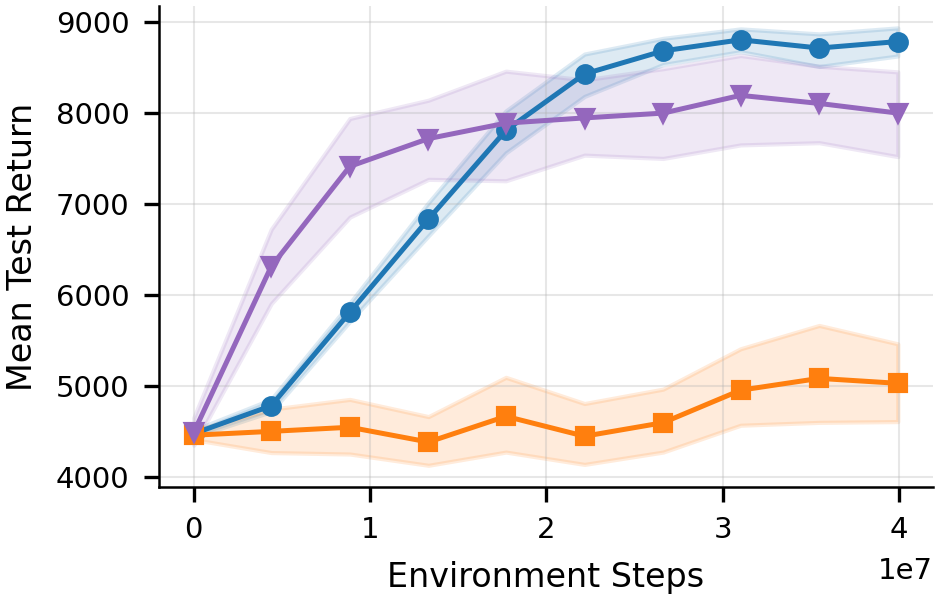

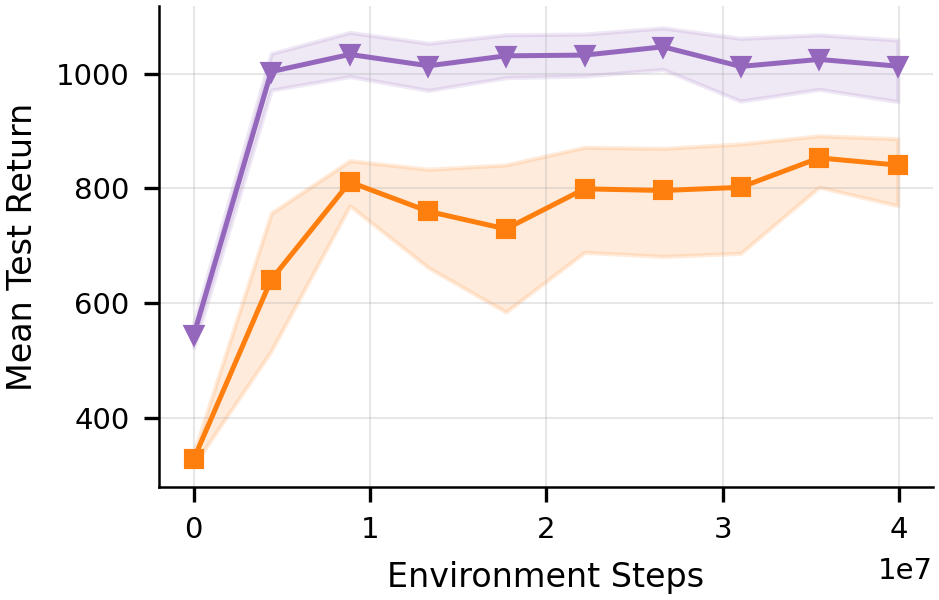

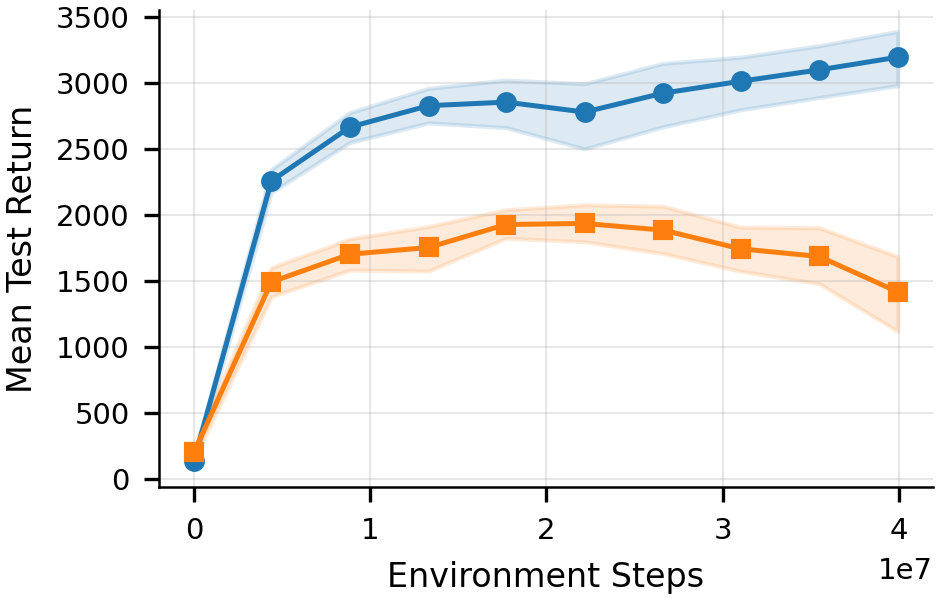

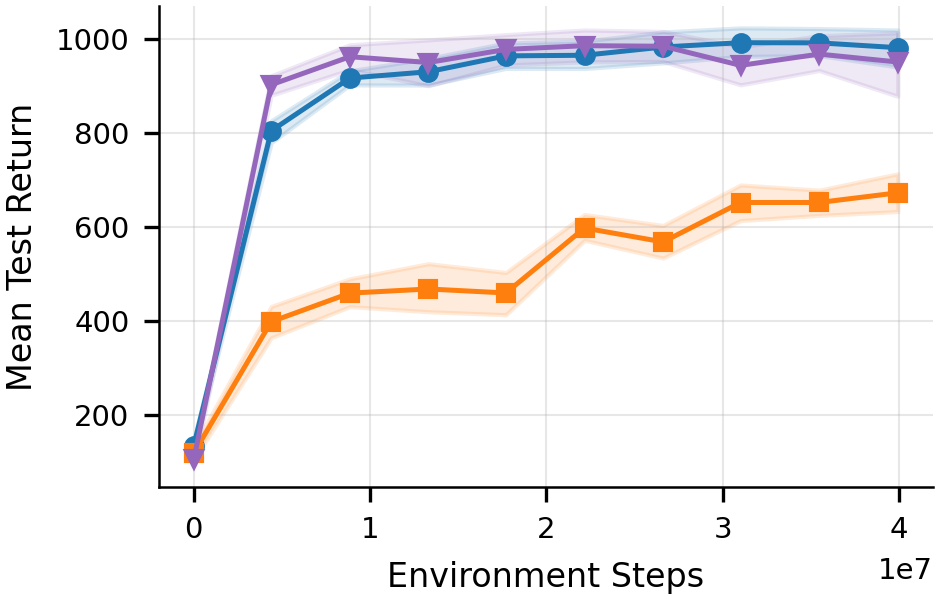

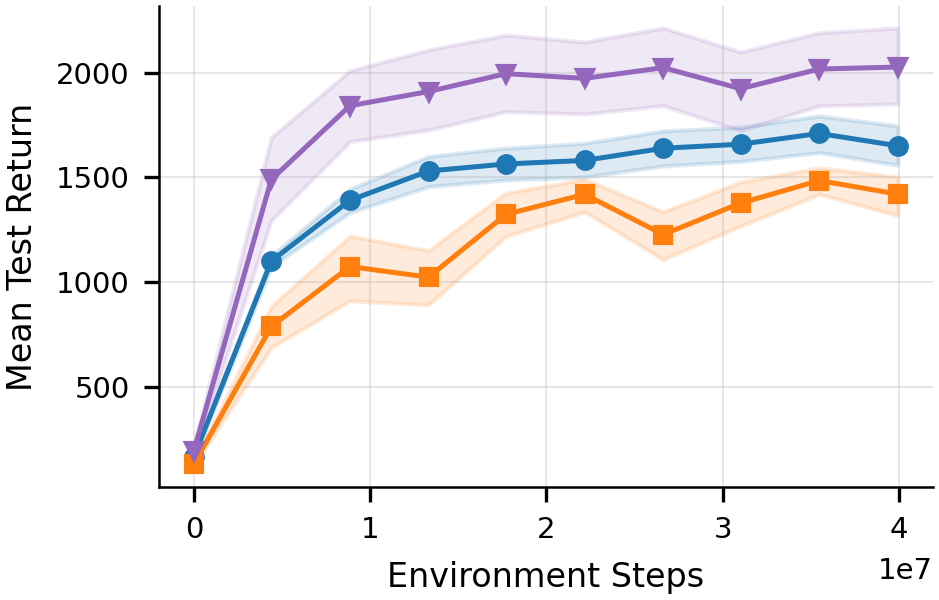

In [12]:
plot_learning_curves(
    collection,
    n_subsample=10,
    save_dir="figs/",
    usetex_fallback=True,
)

In [13]:
# Shared legend for per-environment learning curves
plot_shared_legend(
    collection.algo_names,
    save_path="figs/legend.pdf",
    usetex_fallback=True,
)

Saved figure to figs/legend.pdf


<Figure size 2025x120 with 0 Axes>

## Normalized Learning Curves (Aggregate)

Saved figure to figs/norm_curves.pdf


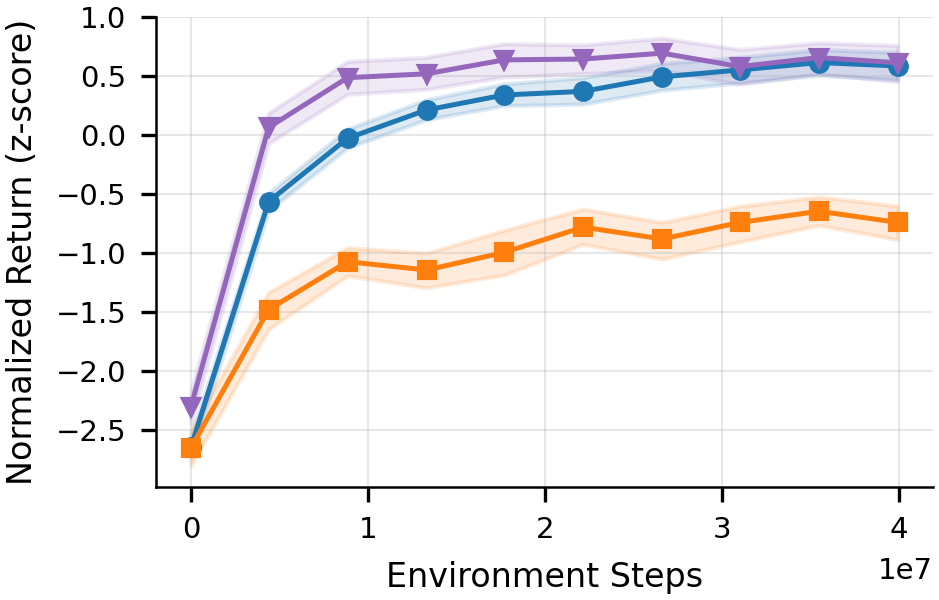

In [14]:
plot_normalized_learning_curves(
    collection,
    n_subsample=10,
    save_path="figs/norm_curves.pdf",
    usetex_fallback=True,
)

## Final Returns per Environment

Saved figure to figs/armmanipulation_final_returns.pdf
Saved figure to figs/bedbathing_final_returns.pdf
Saved figure to figs/feeding_final_returns.pdf
Saved figure to figs/scratchitch_final_returns.pdf
Saved figure to figs/teethbrushing_final_returns.pdf


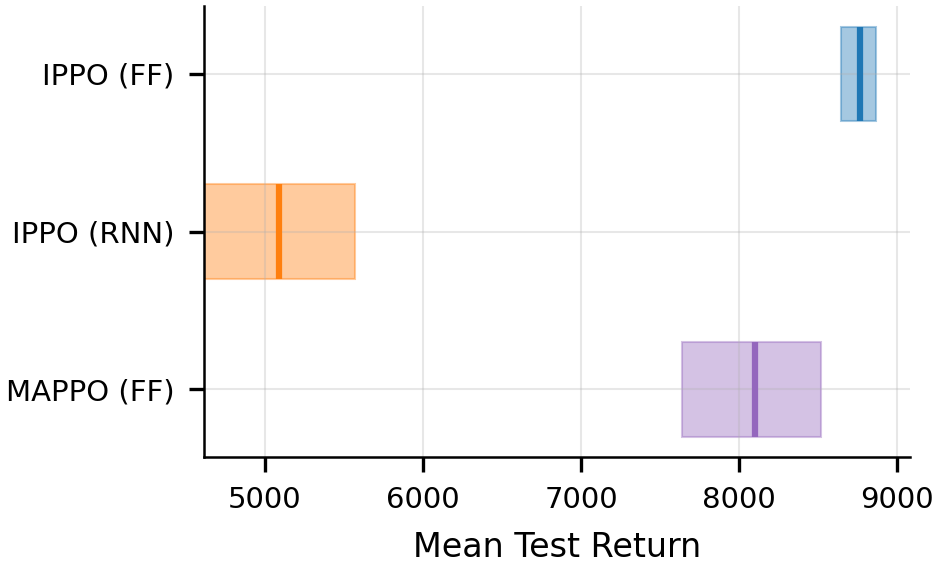

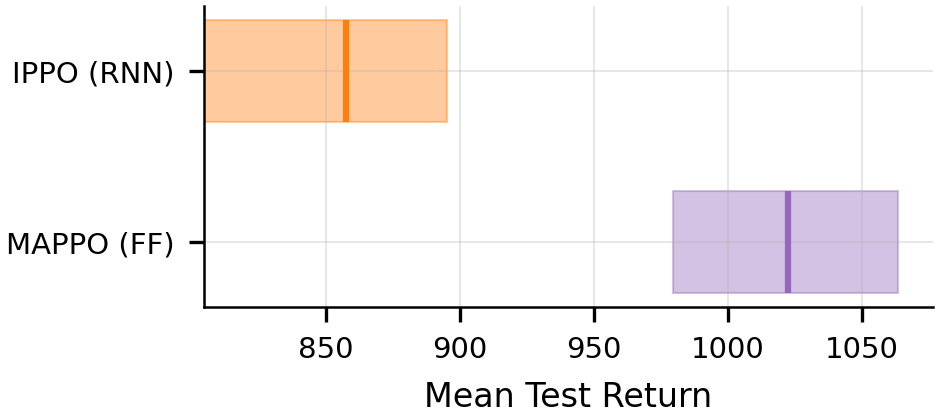

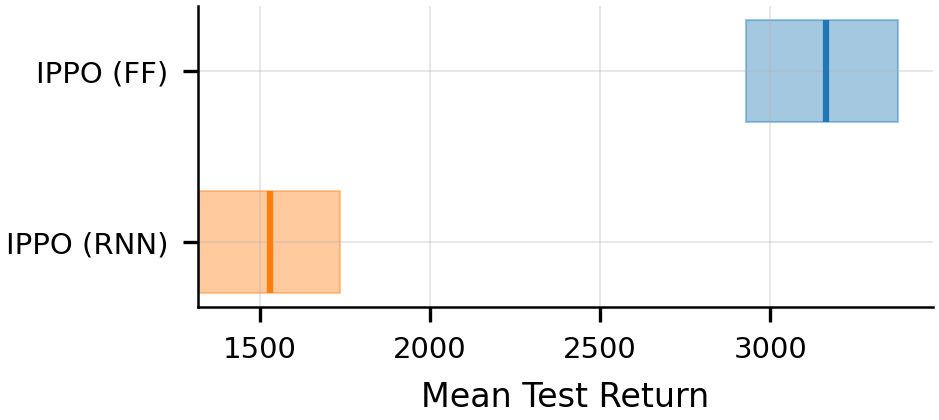

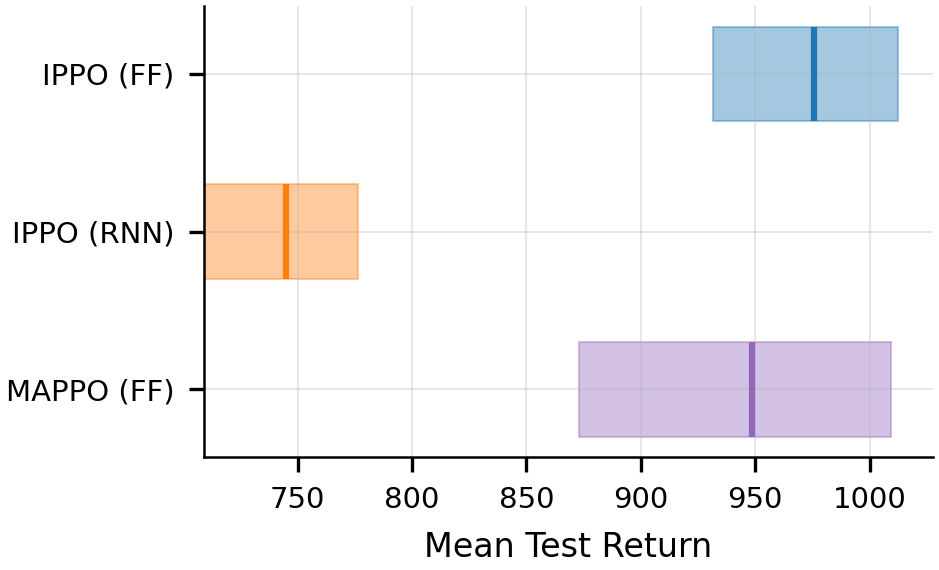

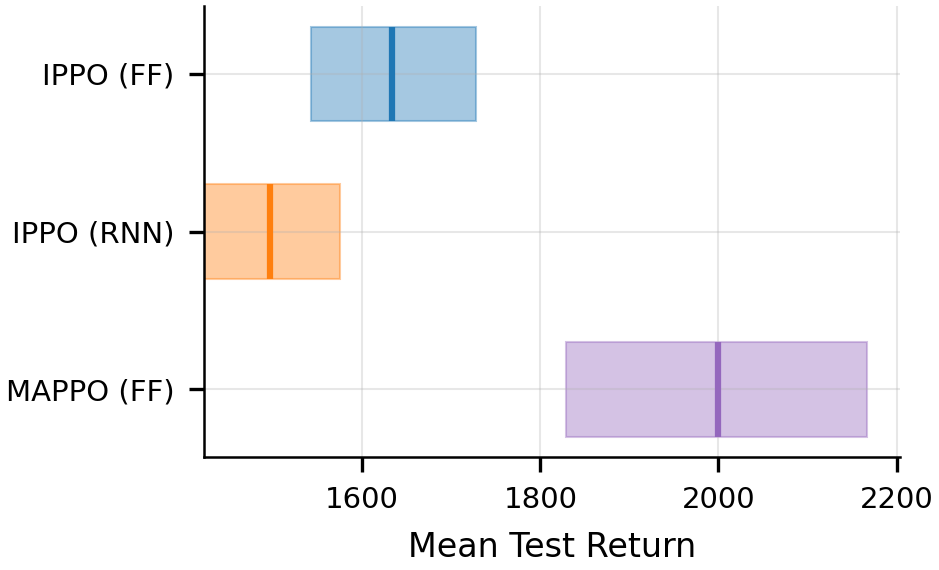

In [15]:
plot_final_returns(
    collection,
    final_n=10,
    save_dir="figs/",
    usetex_fallback=True,
)

## Aggregate Normalized Final Returns

Saved figure to figs/agg_norm.pdf


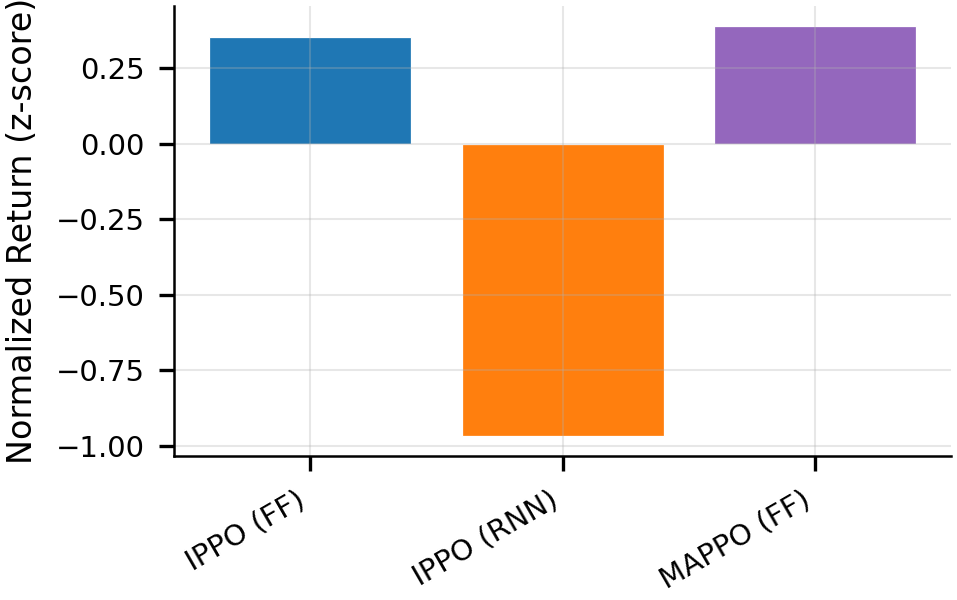

In [16]:
plot_aggregate_normalized_returns(
    collection,
    final_n=10,
    save_path="figs/agg_norm.pdf",
    usetex_fallback=True,
)

## Min-Max Normalized Learning Curves

Saved figure to figs/norm_curves_minmax.pdf


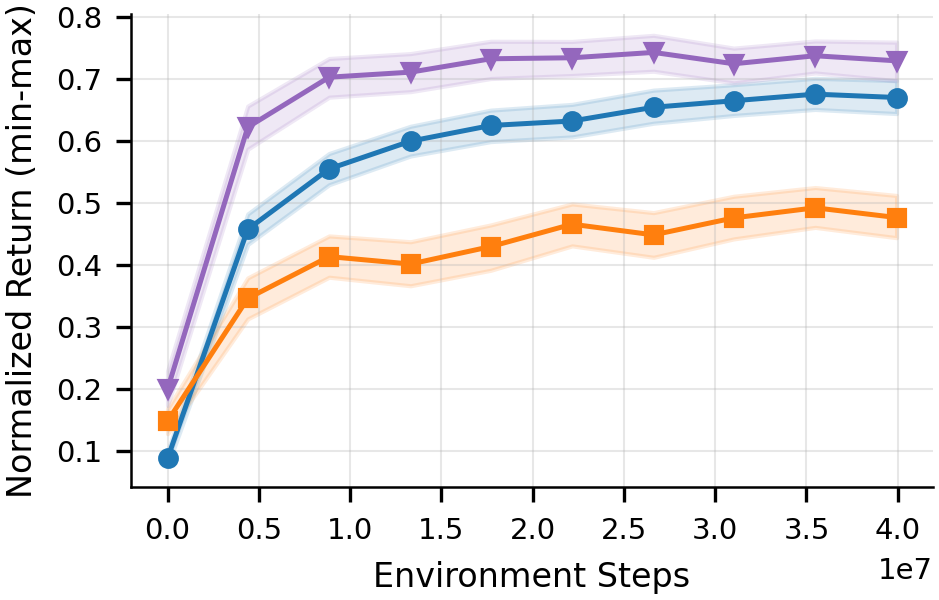

In [17]:
plot_normalized_learning_curves(
    collection,
    n_subsample=10,
    normalization="minmax",
    save_path="figs/norm_curves_minmax.pdf",
    usetex_fallback=True,
)

## Min-Max Aggregate Normalized Returns

Saved figure to figs/agg_norm_minmax.pdf


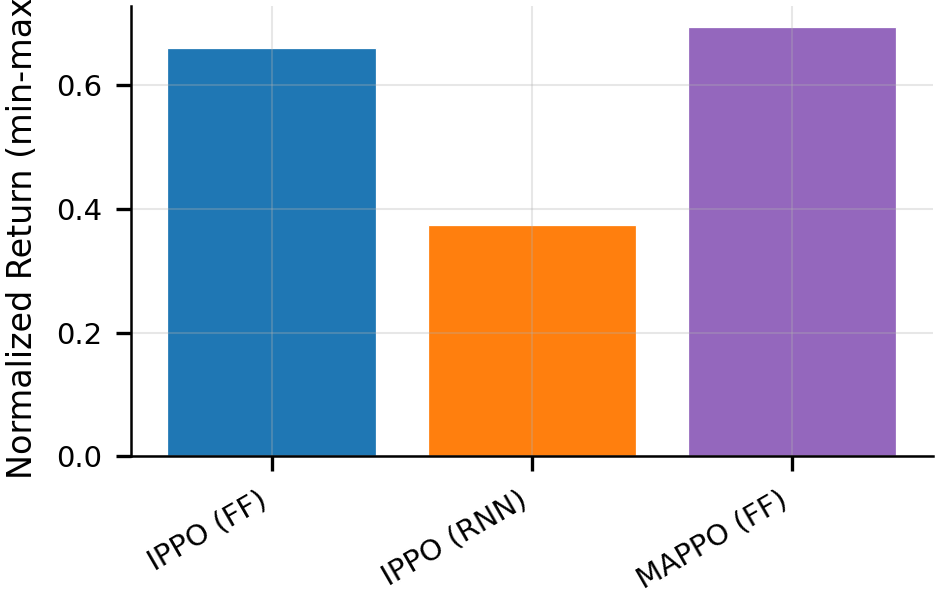

In [18]:
plot_aggregate_normalized_returns(
    collection,
    final_n=10,
    normalization="minmax",
    save_path="figs/agg_norm_minmax.pdf",
    usetex_fallback=True,
)

## PREF vs Non-PREF Comparison

Build a second collection that includes the `PREF` tag and compare
side-by-side with the non-PREF collection above.

In [19]:
# Build PREF collection
PREF_SPEC = {
    "algorithms": {
        algo_name: {
            "base_tags": cfg["base_tags"] + ["PREF"]
        }
        for algo_name, cfg in EXPERIMENT_SPEC["algorithms"].items()
    },
    "environments": EXPERIMENT_SPEC["environments"],
}

pref_collection = build_experiment_collection(PREF_SPEC, exclude_pref=False)

  Found 1 runs for tags ['MARL_FINAL', 'IPPO', 'FF_NPS', 'PREF', 'scratchitch']
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'RNN_NPS', 'PREF', 'scratchitch']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'RNN_NPS', 'PREF', 'scratchitch']
[WARN] Skipping IPPO (RNN) / scratchitch — no data found
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'FF_PS', 'PREF', 'scratchitch']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'FF_PS', 'PREF', 'scratchitch']
[WARN] Skipping IPPO (FF, PS) / scratchitch — no data found
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'RNN_PS', 'PREF', 'scratchitch']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'RNN_PS', 'PREF', 'scratchitch']
[WARN] Skipping IPPO (RNN, PS) / scratchitch — no data found
  Found 1 runs for tags ['MARL_FINAL', 'MAPPO', 'FF_NPS', 'PREF', 'scratchitch']
  Found 0 runs for tags ['MARL_FINAL', 'MAPPO', 'RNN_NPS', 'PREF', 'scratchitch']
[WARN] No runs found for tags ['MARL_FINAL', 'MAPPO', 'RNN_NPS', 'PREF', 'scratch

Saved figure to figs/pref_comparison_without.pdf


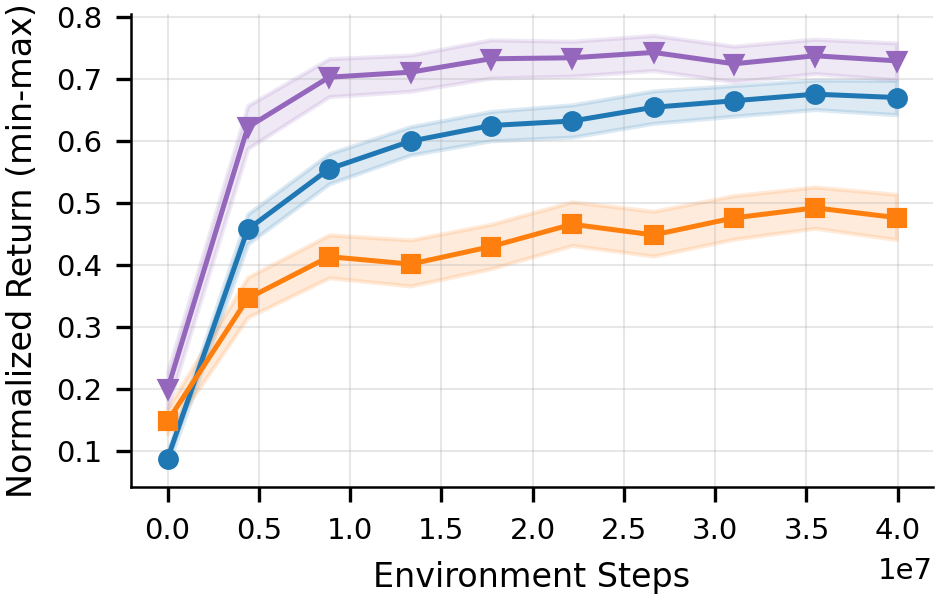

In [20]:
# Without PREF — normalized learning curves (min-max)
plot_normalized_learning_curves(
    collection,
    n_subsample=10,
    normalization="minmax",
    save_path="figs/pref_comparison_without.pdf",
    usetex_fallback=True,
)

Saved figure to figs/pref_comparison_with.pdf


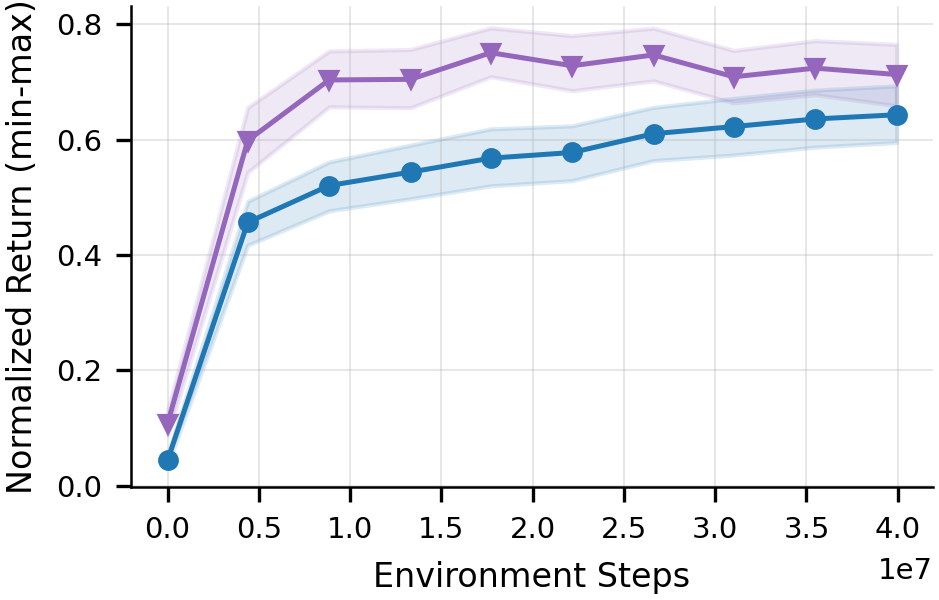

In [21]:
# With PREF — normalized learning curves (min-max)
plot_normalized_learning_curves(
    pref_collection,
    n_subsample=10,
    normalization="minmax",
    save_path="figs/pref_comparison_with.pdf",
    usetex_fallback=True,
)

In [22]:
# Shared legend for pref comparison plots
plot_shared_legend(
    collection.algo_names,
    save_path="figs/pref_legend.pdf",
    usetex_fallback=True,
)

Saved figure to figs/pref_legend.pdf


<Figure size 2025x120 with 0 Axes>

## Crossplay Heatmaps

Saved: figs/crossplay_ippo.png


{'IPPO': (<Figure size 999x999 with 2 Axes>,
  <Axes: title={'center': 'IPPO — Scratch Itch'}, xlabel='Human policy index', ylabel='Robot policy index'>)}

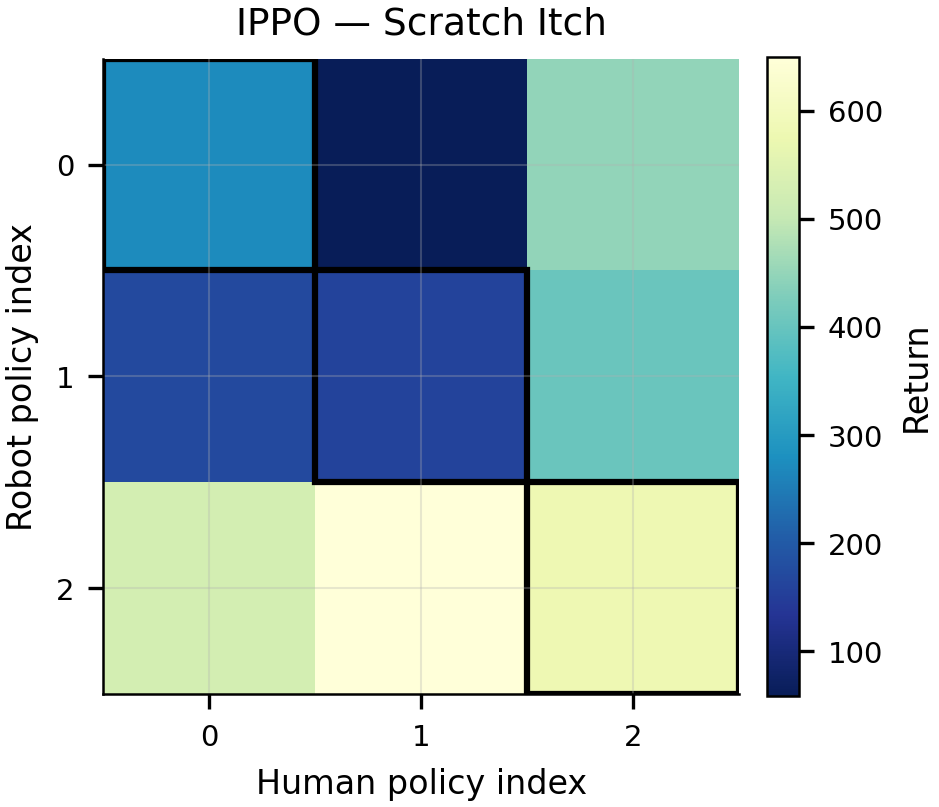

In [2]:
from assistax.baselines.crossplay_plots import plot_all_crossplay

crossplay_results_path = "/home/leo/assistive-autonomy-github/assistax/outputs/crossplay/scratchitch/2026-03-02/14-17-11/crossplay_results_0_68.npy"  # TODO: update path

plot_all_crossplay(
    results_path=crossplay_results_path,
    save_dir="figs/",
    env_name="scratchitch",
    usetex_fallback=True,
)